# Οπτικοποίηση Αρχιτεκτονικής Κβαντικού Κυκλώματος (VQC)

Στο παρακάτω κελί, απομονώνουμε αποκλειστικά τον κώδικα που κατασκευάζει την αρχιτεκτονική του κβαντικού μας μοντέλου. Σκοπός είναι να εξαγάγουμε το σχεδιάγραμμα του κυκλώματος **χωρίς να χρειαστεί να εκτελέσουμε ξανά την εξαιρετικά χρονοβόρα διαδικασία της εκπαίδευσης (training)** ή να φορτώσουμε το πλήρες dataset.

Για να επιτευχθεί αυτό με αυτόνομο τρόπο, χρησιμοποιούμε τα εξής:
* **State Preparation (Amplitude Encoding):** Δημιουργούμε ένα "εικονικό" (dummy) κανονικοποιημένο διάνυσμα 16 διαστάσεων. Η Qiskit χρειάζεται απλώς τις σωστές διαστάσεις για να "χτίσει" το block, οπότε δεν απαιτούνται τα πραγματικά δεδομένα του NSL-KDD.
* **Feature Map & Ansatz:** Ενώνουμε το `raw_feature_vector` (16 features) με το `RealAmplitudes` ansatz (4 qubits, reps=5), διατηρώντας ακριβώς την ίδια δομή που είχε το τελικό μας μοντέλο.


--- 0. Setup: Προετοιμασία Παραμέτρων, Δεδομένων & Αποθήκευσης ---
 Οι φωτογραφίες θα αποθηκεύονται αυτόματα στο:
/home/aggelos/Documents/projects/Quantum-IDS-NSLKDD/photos

--- 1. Γενική Επισκόπηση: Αρχιτεκτονική VQC ---


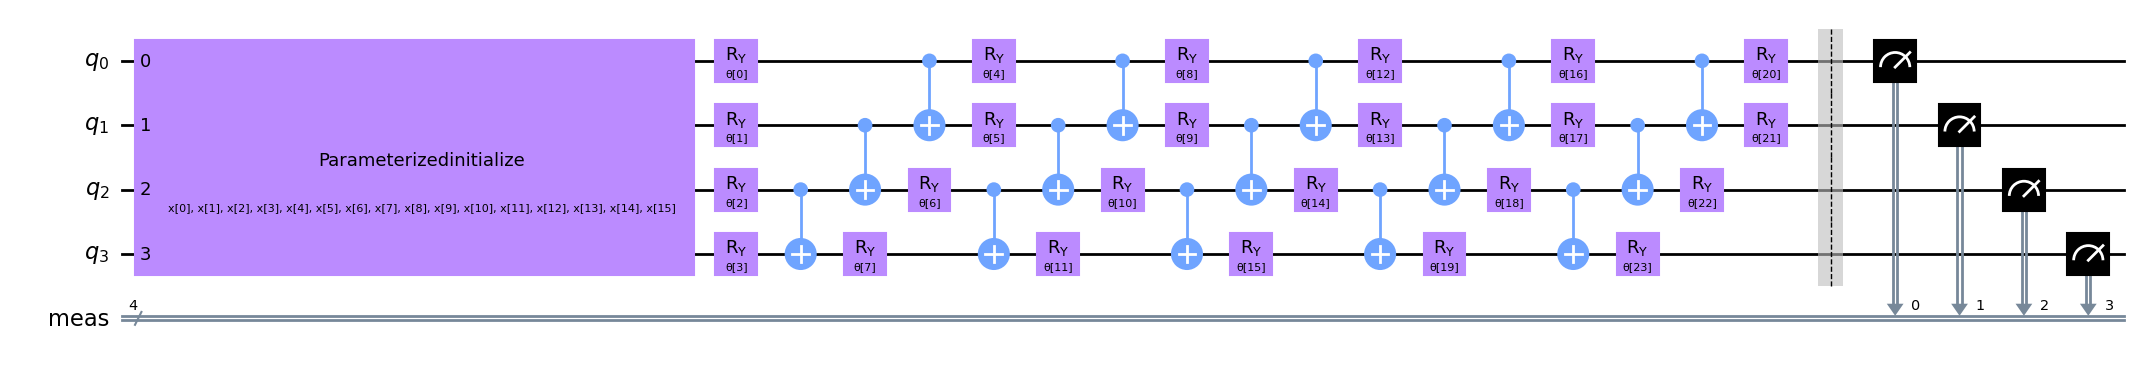


--- 2. Αναλυτική Εξέταση: STATE 1 (Feature Map - data preparation) ---
Απαιτούμενα Qubits για data loading: 4
Βάθος κυκλώματος fm: 24



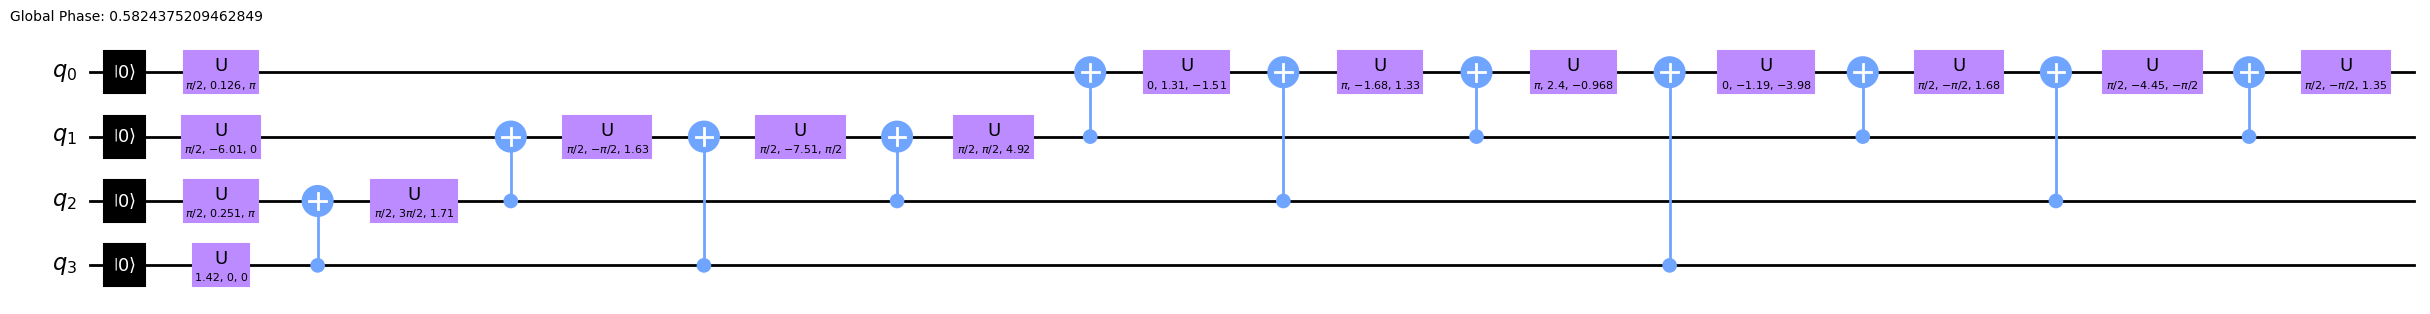


--- 3. Αναλυτική Εξέταση: STATE 2 (Ansatz - training structure) ---
Απαιτούμενα Qubits για το μοντέλο: 4
Βάθος κυκλώματος ansatz: 17
Συνολικές εκπαιδεύσιμες παράμετροι θ: 24



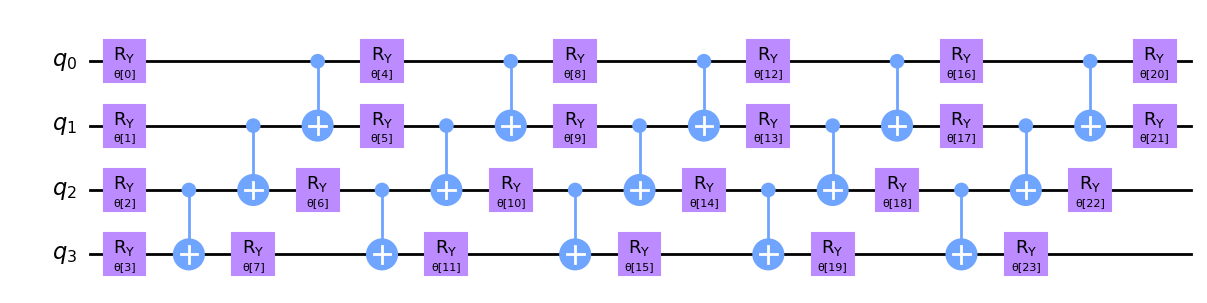


--- 4. Εννοιολογικό Template: Δομή ΜΙΑΣ Επανάληψης (RY layer + CNOT Entangler) ---


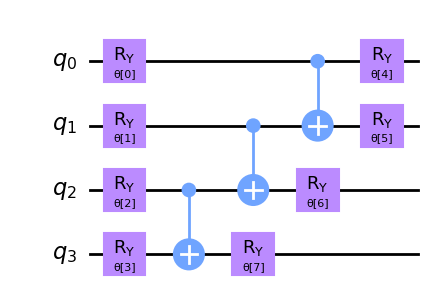

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import real_amplitudes
from qiskit_machine_learning.circuit.library import raw_feature_vector


print("--- 0. Setup: Προετοιμασία Παραμέτρων, Δεδομένων & Αποθήκευσης ---")
num_qubits = 4
feature_dim = 16
reps = 5

# Ορισμός και δημιουργία του φακέλου αποθήκευσης αν δεν υπάρχει
photos_dir = os.path.expanduser('~/Documents/projects/Quantum-IDS-NSLKDD/photos')
os.makedirs(photos_dir, exist_ok=True)
print(f" Οι φωτογραφίες θα αποθηκεύονται αυτόματα στο:\n{photos_dir}")


dummy_data = np.random.rand(feature_dim)
dummy_data = dummy_data / np.linalg.norm(dummy_data)

current_style = 'clifford'


print("\n--- 1. Γενική Επισκόπηση: Αρχιτεκτονική VQC ---")


feature_map_circuit = raw_feature_vector(feature_dimension=feature_dim)
feature_map_circuit.name = "Feature Map (Data loading: x)"

# Ansatz (RealAmplitudes: 4 Qubits, 5 reps = 24 parameters θ)
ansatz_amp = real_amplitudes(num_qubits=num_qubits, reps=reps)
ansatz_amp.name = "Ansatz (Model: θ)"


vqc_overview = feature_map_circuit.compose(ansatz_amp)
vqc_overview.measure_all() 
fig_overview = vqc_overview.draw(output='mpl', style=current_style, fold=-1)
fig_overview.savefig(os.path.join(photos_dir, '1_vqc_overview.png'), dpi=300, bbox_inches='tight', facecolor='white')
display(fig_overview)

print("\n--- 2. Αναλυτική Εξέταση: STATE 1 (Feature Map - data preparation) ---")

bound_feature_map = feature_map_circuit.assign_parameters(dummy_data)

fm_flat = transpile(bound_feature_map, basis_gates=['u', 'cx'], optimization_level=0)

print(f"Απαιτούμενα Qubits για data loading: {fm_flat.num_qubits}")
print(f"Βάθος κυκλώματος fm: {fm_flat.depth()}\n")


fig1 = fm_flat.draw(output='mpl', style=current_style, fold=-1)
fig1.savefig(os.path.join(photos_dir, '2_feature_map_detailed.png'), dpi=300, bbox_inches='tight', facecolor='white')
display(fig1)


print("\n--- 3. Αναλυτική Εξέταση: STATE 2 (Ansatz - training structure) ---")

ansatz_flat = transpile(ansatz_amp, basis_gates=['ry', 'cx'], optimization_level=0)

print(f"Απαιτούμενα Qubits για το μοντέλο: {ansatz_flat.num_qubits}")
print(f"Βάθος κυκλώματος ansatz: {ansatz_flat.depth()}")
print(f"Συνολικές εκπαιδεύσιμες παράμετροι θ: {ansatz_flat.num_parameters}\n")

fig2 = ansatz_flat.draw(output='mpl', style=current_style, fold=-1)
fig2.savefig(os.path.join(photos_dir, '3_ansatz_detailed.png'), dpi=300, bbox_inches='tight', facecolor='white')
display(fig2)

print("\n--- 4. Εννοιολογικό Template: Δομή ΜΙΑΣ Επανάληψης (RY layer + CNOT Entangler) ---")
single_rep = real_amplitudes(num_qubits=4, reps=1)

# Σχεδίαση, Αποθήκευση και Εμφάνιση
fig_template = transpile(single_rep, basis_gates=['ry', 'cx'], optimization_level=0).draw(output='mpl', style=current_style)
fig_template.savefig(os.path.join(photos_dir, '4_ansatz_single_rep.png'), dpi=300, bbox_inches='tight', facecolor='white')
display(fig_template)